<a href="https://colab.research.google.com/github/anabelpoulard13-boop/ensight_concentration_analysis/blob/main/Concentration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of the code

It analyses the input of the Ensight machine. This code will allow you to analyse the growth of the cells in each well of a plate. It will generate a heatmap of the cell that reached the threshold of growth establish prior to the analysis.

# Variable

The following information is an established variable, the threshold. This is estabished prior to the star of the code to allow users to change it without having to look into the code and change information in the core of the code. The threshold variable is the variable that python will compare the data table you will be giving him. Depending on the experiement the growth analysis, this variable may change. Therefore you can change it as mush a you like and the code will evaluate all the cell having that variable as the core of the analysis.

In [18]:
threshold = 0.2

In [19]:
import pandas as pd
import string

file_path = 'GroupA.csv'

df = pd.read_csv(file_path, skiprows = 9, nrows = 16)

table_data = df.iloc[0:16, 1:25] # define all the line here
current_data_cols = table_data.columns.tolist()
table_data[current_data_cols] = table_data[current_data_cols].apply(pd.to_numeric, errors='coerce')


row_labels = [string.ascii_uppercase[i] for i in range(len(table_data))]
table_data.insert(0, 'Row_Label', row_labels)

display(table_data.head())

,Row_Label,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A,0.463,0.124,0.524,0.145,0.249,0.647,0.270,0.443,0.276,...,0.707,0.585,0.548,0.462,0.471,0.435,0.463,0.454,0.204,0.910
1,B,0.598,0.478,0.495,0.382,0.393,0.624,0.602,0.571,0.475,...,0.792,0.358,0.466,0.291,0.319,0.452,0.274,0.498,0.585,0.624
2,C,0.452,0.372,0.289,0.403,0.364,0.533,0.407,0.518,0.319,...,0.573,0.563,0.441,0.446,0.364,0.360,0.452,0.475,0.567,0.133
3,D,0.374,0.397,0.469,0.596,0.477,0.341,0.374,0.627,0.344,...,0.621,0.410,0.438,0.463,0.295,0.176,0.252,0.484,0.399,0.210
4,E,0.296,0.268,0.514,0.320,0.299,0.363,0.275,0.541,0.357,...,0.460,0.523,0.429,0.344,0.246,0.427,0.672,0.283,0.448,0.450


In [20]:
import matplotlib.pyplot as plt
import numpy as np

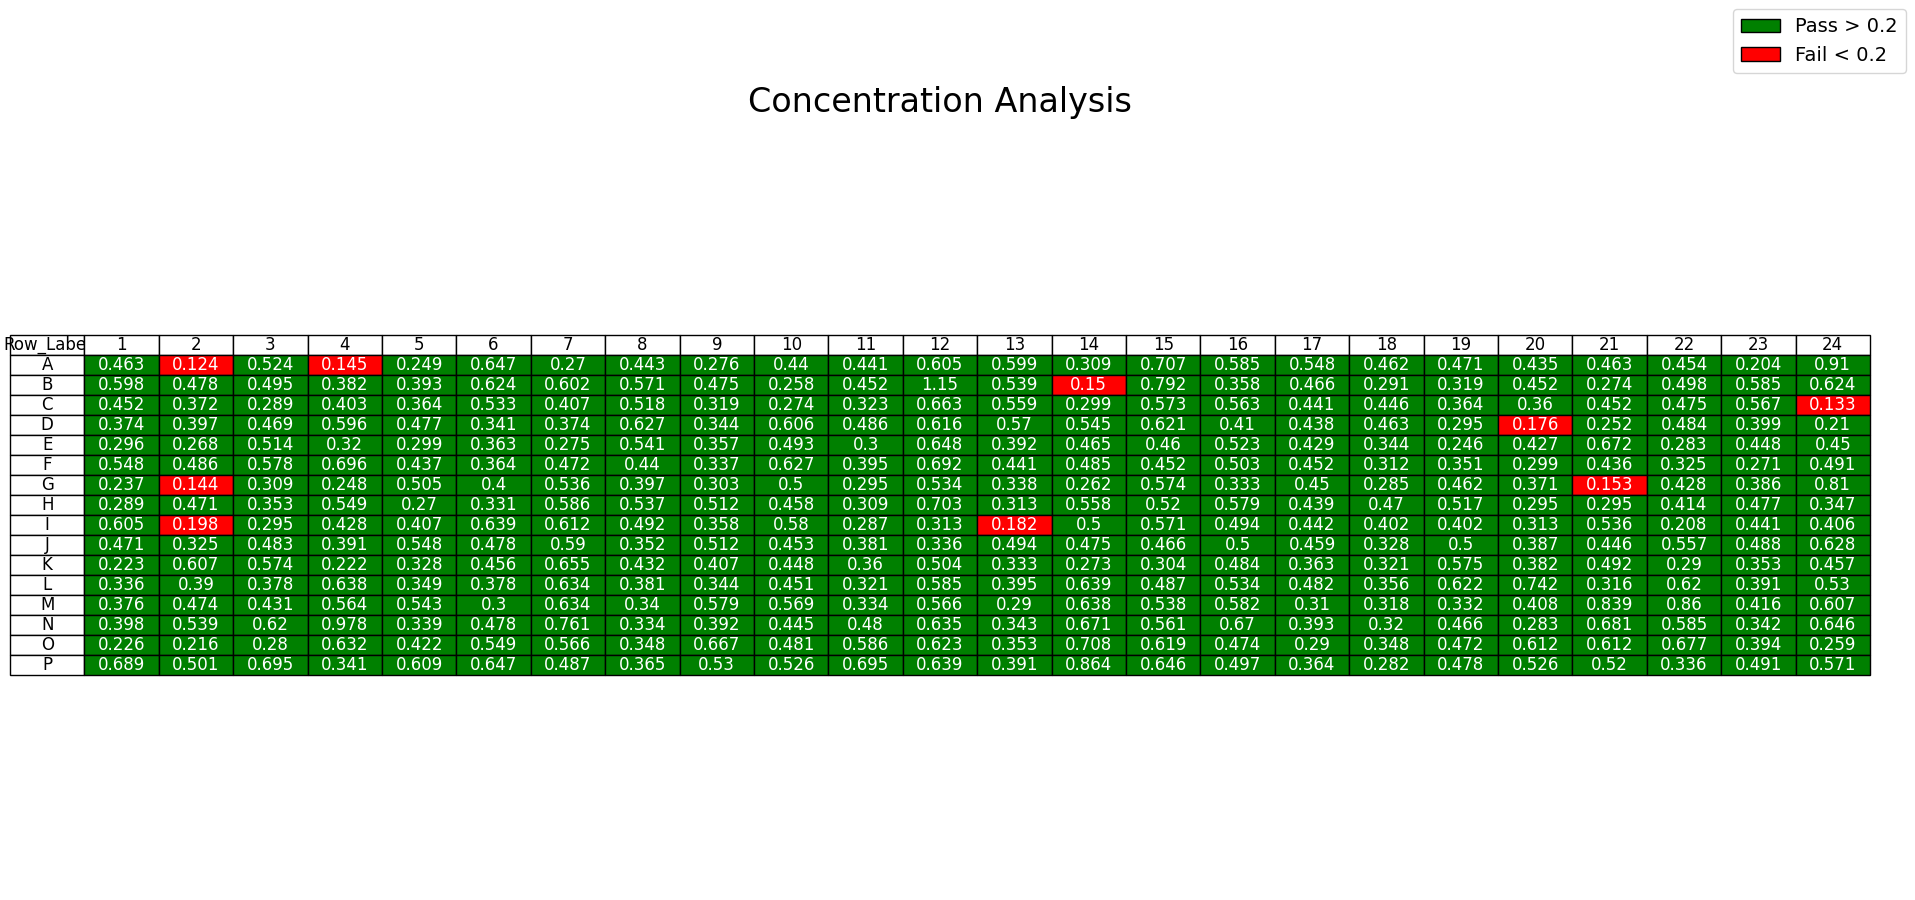

Passed wells, ['A1', 'A3', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'B22', 'B23', 'B24', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D21', 'D22', 'D23', 'D24', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'G1', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G

In [29]:
pass_wells = []
fail_wells = []

fig, ax = plt.subplots(figsize = (20, 10))
ax.axis('off')

table = ax.table(cellText = table_data.values, colLabels =table_data.columns, loc = 'center', cellLoc = 'center')
for (i,j), val in table.get_celld().items():
  if i > 0 :
    cell_value = table_data.iloc[i-1, j]
    if isinstance(cell_value, (int, float)):
      if cell_value < threshold:
        color = 'red'
        fail_wells.append(f'{table_data.iloc[i-1, 0]}{j}')
      else:
        color = 'green'
        pass_wells.append(f'{table_data.iloc[i-1,0]}{j}')
      val.set_facecolor(color)
      val.set_text_props(color = 'white')

from matplotlib.patches import Patch
legend_element = [
  Patch(facecolor = 'green', edgecolor = 'black', label = f'Pass > {threshold}'),
  Patch(facecolor = 'red', edgecolor = 'black', label = f'Fail < {threshold}')
]
fig.legend(handles = legend_element, loc = 'upper right', fontsize = 14)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.title('Concentration Analysis', fontsize = 24)
plt.show()


print(f'Passed wells, {pass_wells}')
print(f'Failed wells, {fail_wells}')